# 🧠 Pipeline ML Complet — Prédiction de Tumeur Cérébrale

> **Auteur :** Expert Data Science / Machine Learning  
> **Objectifs :**
> - 🎯 Prédire si un patient a une tumeur cérébrale (`Brain_Tumor_Present` : 0 ou 1)
> - 🧬 Prédire le type de tumeur (`Tumor_Type`)

---

## 📋 Table des matières
1. [Analyse du Dataset](#section1)
2. [Nettoyage des données](#section2)
3. [Analyse Exploratoire (EDA)](#section3)
4. [Préparation des données](#section4)
5. [Modélisation](#section5)
6. [Évaluation](#section6)
7. [Explication des résultats](#section7)
8. [Bonus](#section8)


## ⚙️ 0. Imports & Configuration

On commence par importer toutes les librairies nécessaires.
- **pandas / numpy** : manipulation des données
- **matplotlib / seaborn** : visualisations
- **sklearn** : modèles de Machine Learning


In [1]:
# ─── Librairies de base ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Sklearn : prétraitement ───────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ─── Sklearn : modèles ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ─── Sklearn : métriques ──────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ─── Style global ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✅ Toutes les librairies importées avec succès !')

✅ Toutes les librairies importées avec succès !


In [2]:

df = pd.read_csv('Brain_Tumor_Prediction_Dataset.csv')



---
<a id='section1'></a>
## 🔍 Section 1 — Analyse du Dataset

Avant tout modèle, il faut **comprendre** les données :
- Quels types de variables avons-nous ?
- Y a-t-il des données manquantes ?
- Les classes sont-elles équilibrées ?


### 1.1 — Aperçu des 5 premières lignes


In [3]:
df.head()

,Age,Gender,Country,Tumor_Size,Tumor_Location,MRI_Findings,Genetic_Risk,Smoking_History,Alcohol_Consumption,Radiation_Exposure,Head_Injury_History,Chronic_Illness,Blood_Pressure,Diabetes,Tumor_Type,Treatment_Received,Survival_Rate(%),Tumor_Growth_Rate,Family_History,Symptom_Severity,Brain_Tumor_Present
0,66,Other,China,8.7000,Cerebellum,Severe,81,No,Yes,Medium,No,Yes,122/88,No,Malignant,NaN,58,Slow,Yes,Mild,No
1,87,Female,Australia,8.1400,Temporal,Normal,65,No,Yes,Medium,No,No,126/119,No,Malignant,NaN,13,Rapid,Yes,Severe,No
2,41,Male,Canada,6.0200,Occipital,Severe,100,Yes,No,Low,Yes,No,118/65,No,Benign,Chemotherapy,67,Slow,Yes,Moderate,Yes
3,52,Male,Japan,7.2600,Occipital,Normal,19,Yes,Yes,High,Yes,No,165/119,Yes,Benign,Radiation,85,Moderate,No,Moderate,Yes
4,84,Female,Brazil,7.9400,Temporal,Abnormal,47,No,Yes,Medium,No,Yes,156/97,Yes,Malignant,NaN,17,Moderate,No,Moderate,No


### 1.2 — Types de données et informations générales


In [4]:
print('─' * 50)
print('TYPES DE DONNÉES')
print('─' * 50)
print(df.dtypes)
print(f'\nDimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')

──────────────────────────────────────────────────
TYPES DE DONNÉES
──────────────────────────────────────────────────
Age                      int64
Gender                     str
Country                    str
Tumor_Size             float64
Tumor_Location             str
MRI_Findings               str
Genetic_Risk             int64
Smoking_History            str
Alcohol_Consumption        str
Radiation_Exposure         str
Head_Injury_History        str
Chronic_Illness            str
Blood_Pressure             str
Diabetes                   str
Tumor_Type                 str
Treatment_Received         str
Survival_Rate(%)         int64
Tumor_Growth_Rate          str
Family_History             str
Symptom_Severity           str
Brain_Tumor_Present        str
dtype: object

Dimensions : 250000 lignes × 21 colonnes


### 1.3 — Statistiques descriptives


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,250000.0000,NaN,NaN,NaN,46.9624,24.5171,5.0000,26.0000,47.0000,68.0000,89.0000
Gender,250000,3,Male,83407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,250000,12,Brazil,20985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tumor_Size,250000.0000,NaN,NaN,NaN,5.2518,2.7426,0.5000,2.8700,5.2600,7.6300,10.0000
Tumor_Location,250000,5,Parietal,50187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MRI_Findings,250000,3,Abnormal,83737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genetic_Risk,250000.0000,NaN,NaN,NaN,49.9989,29.1780,0.0000,25.0000,50.0000,75.0000,100.0000
Smoking_History,250000,2,Yes,125150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alcohol_Consumption,250000,2,Yes,125173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Radiation_Exposure,250000,3,Low,83513,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 — Valeurs manquantes

> 💡 Les valeurs manquantes peuvent biaiser les modèles. On les détecte ici avant de les traiter.


⚠️  1 colonne(s) avec des valeurs manquantes :



,Valeurs manquantes,Pourcentage (%)
Treatment_Received,62748,25.1000


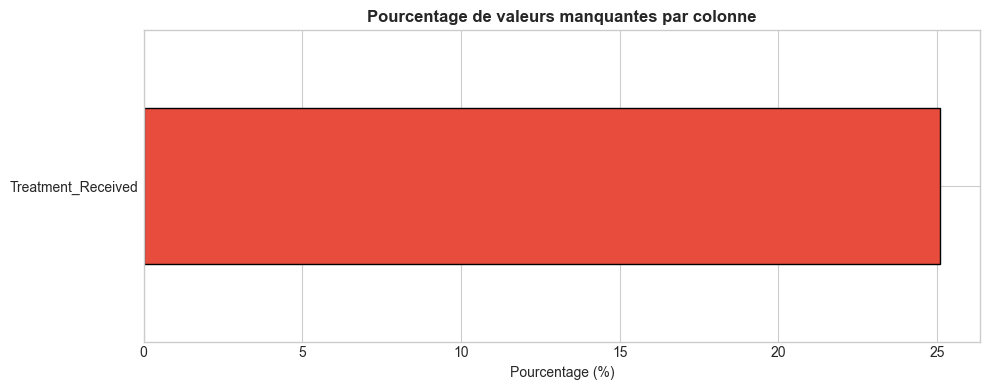

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).sort_values('Valeurs manquantes', ascending=False)

missing_positive = missing_df[missing_df['Valeurs manquantes'] > 0]

if missing_positive.empty:
    print('✅ Aucune valeur manquante !')
else:
    print(f'⚠️  {len(missing_positive)} colonne(s) avec des valeurs manquantes :\n')
    display(missing_positive)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 4))
missing_positive['Pourcentage (%)'].plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='black')
ax.set_title('Pourcentage de valeurs manquantes par colonne', fontsize=12, fontweight='bold')
ax.set_xlabel('Pourcentage (%)')
plt.tight_layout()
plt.show()

### 1.5 — Doublons


In [7]:
dups = df.duplicated().sum()
print(f'Nombre de doublons : {dups}')
if dups == 0:
    print('✅ Aucun doublon trouvé.')
else:
    print(f'⚠️  {dups} ligne(s) dupliquée(s) à supprimer.')

Nombre de doublons : 0
✅ Aucun doublon trouvé.


### 1.6 — Équilibre de la variable cible `Brain_Tumor_Present`




Distribution Brain_Tumor_Present :
                     Nb patients  Pourcentage (%)
Brain_Tumor_Present                              
No                        125118          50.0500
Yes                       124882          49.9500


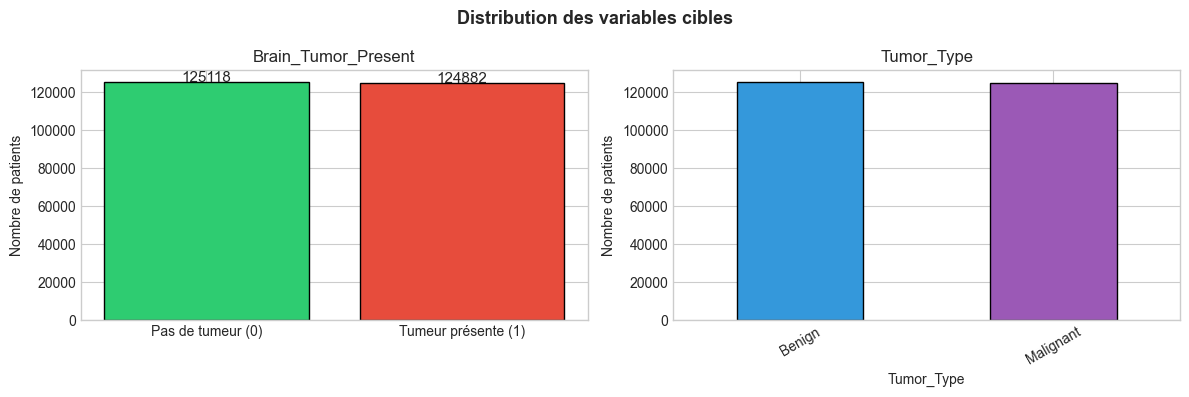

In [8]:
counts = df['Brain_Tumor_Present'].value_counts()
pcts   = df['Brain_Tumor_Present'].value_counts(normalize=True) * 100

print('Distribution Brain_Tumor_Present :')
print(pd.DataFrame({'Nb patients': counts, 'Pourcentage (%)': pcts.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution des variables cibles', fontsize=13, fontweight='bold')

# Brain_Tumor_Present
axes[0].bar(['Pas de tumeur (0)', 'Tumeur présente (1)'],
            counts.sort_index(), color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Brain_Tumor_Present')
axes[0].set_ylabel('Nombre de patients')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 8,
                 f'{bar.get_height():.0f}', ha='center', fontsize=11)

# Tumor_Type
df['Tumor_Type'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#3498db','#9b59b6','#e67e22','#1abc9c'], edgecolor='black')
axes[1].set_title('Tumor_Type')
axes[1].set_ylabel('Nombre de patients')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
<a id='section2'></a>
## 🧹 Section 2 — Nettoyage des Données

Le nettoyage est **crucial** : un mauvais dataset donne un mauvais modèle.
Étapes :
1. Supprimer les doublons
2. ⚠️ Éliminer le **data leakage**
3. Imputer les valeurs manquantes
4. Encoder les variables catégorielles
5. Normaliser les variables numériques


### 2.1 — Suppression des doublons


In [9]:
df_clean = df.copy()
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Doublons supprimés : {before - len(df_clean)}')
print(f'Shape après suppression : {df_clean.shape}')

Doublons supprimés : 0
Shape après suppression : (250000, 21)


### 2.1 — ⚠️ Élimination du Data Leakage

**Le data leakage** = inclure dans le modèle des informations qui ne seraient
**pas disponibles** au moment réel de la prédiction.

| Colonne | Problème |
|---|---|
| `Survival_Rate(%)` | Calculée **après** diagnostic → le médecin ne la connaît pas encore |
| `Treatment_Received` | Décidé **après** diagnostic → révèle si le patient est malade |

> 🚨 Si on les garde, le modèle aura une accuracy artificielle de ~99%
> mais sera **inutile en production** car ces colonnes n'existent pas encore.


In [10]:
leakage_cols = ['Survival_Rate(%)', 'Treatment_Received']
df_clean.drop(columns=leakage_cols, inplace=True)
print(f'✅ Colonnes data-leakage supprimées : {leakage_cols}')
print(f'Shape après suppression data leakage : {df_clean.shape}')

✅ Colonnes data-leakage supprimées : ['Survival_Rate(%)', 'Treatment_Received']
Shape après suppression data leakage : (250000, 19)


### 2.3 — Gestion des valeurs manquantes

**Stratégie :**
- Variables **numériques** → remplacer par la **moyenne** (robuste aux valeurs extrêmes)
- Variables **catégorielles** → remplacer par le **mode** (valeur la plus fréquente)


In [12]:
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Imputation numérique → moyenne
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        mean_val = df_clean[col].mean()
        df_clean[col].fillna(mean_val, inplace=True)
        print(f'  📊 [{col}] → remplie par la moyenne : {mean_val:.3f}')

# Imputation catégorielle → mode
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'  🔤 [{col}] → remplie par le mode : "{mode_val}"')

total_missing = df_clean.isnull().sum().sum()
print(f'\n✅ Valeurs manquantes restantes : {total_missing}')


✅ Valeurs manquantes restantes : 0


### 2.4 — Encodage des variables catégorielles

Les algorithmes ML ne comprennent que les **nombres**.
On utilise `LabelEncoder` pour transformer :
- `Male` → 0, `Female` → 1
- `Frontal` → 0, `Parietal` → 1, etc.


In [13]:
le = LabelEncoder()

# On encode toutes les catégorielles sauf les cibles
cat_to_encode = [c for c in cat_cols if c not in ['Brain_Tumor_Present', 'Tumor_Type']]

for col in cat_to_encode:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f'  ✅ Encodé : {col}')

print(f'\nShape final après encodage : {df_clean.shape}')
df_clean.head(3)

  ✅ Encodé : Gender
  ✅ Encodé : Country
  ✅ Encodé : Tumor_Location
  ✅ Encodé : MRI_Findings
  ✅ Encodé : Smoking_History
  ✅ Encodé : Alcohol_Consumption
  ✅ Encodé : Radiation_Exposure
  ✅ Encodé : Head_Injury_History
  ✅ Encodé : Chronic_Illness
  ✅ Encodé : Blood_Pressure
  ✅ Encodé : Diabetes
  ✅ Encodé : Tumor_Growth_Rate
  ✅ Encodé : Family_History
  ✅ Encodé : Symptom_Severity

Shape final après encodage : (250000, 19)


,Age,Gender,Country,Tumor_Size,Tumor_Location,MRI_Findings,Genetic_Risk,Smoking_History,Alcohol_Consumption,Radiation_Exposure,Head_Injury_History,Chronic_Illness,Blood_Pressure,Diabetes,Tumor_Type,Tumor_Growth_Rate,Family_History,Symptom_Severity,Brain_Tumor_Present
0,66,2,3,8.7000,0,2,81,0,1,2,0,1,1391,0,Malignant,2,1,0,No
1,87,0,0,8.1400,4,1,65,0,1,2,0,0,1605,0,Malignant,1,1,2,No
2,41,1,2,6.0200,2,2,100,1,0,1,1,0,1124,0,Benign,2,1,1,Yes


### 2.5 — Normalisation des variables numériques

**Pourquoi normaliser ?**
Une variable `Age` (10-85) ne doit pas dominer `Tumor_Size` (0.5-10)
juste parce qu'elle a des valeurs plus grandes.
`StandardScaler` transforme chaque variable : **moyenne = 0, écart-type = 1**.


In [14]:
scaler = StandardScaler()

# On ne normalise PAS les variables cibles
cols_to_scale = [
    c for c in df_clean.select_dtypes(include=['float64', 'int64']).columns
    if c not in ['Brain_Tumor_Present', 'Tumor_Type']
]

df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print(f'✅ Normalisation appliquée sur {len(cols_to_scale)} colonnes.')
print(f'Exemple — Tumor_Size après normalisation : moyenne = {df_clean["Tumor_Size"].mean():.4f}, std = {df_clean["Tumor_Size"].std():.4f}')

✅ Normalisation appliquée sur 17 colonnes.
Exemple — Tumor_Size après normalisation : moyenne = 0.0000, std = 1.0000


---
<a id='section3'></a>
## 📊 Section 3 — Analyse Exploratoire (EDA)

L'EDA permet de **visualiser les relations** entre les variables
et de mieux comprendre ce qui influence la présence d'une tumeur.


### 3.1 — Heatmap de corrélation

> Une corrélation proche de **+1** ou **-1** indique une forte relation linéaire.
> Une corrélation proche de **0** indique peu de relation linéaire.


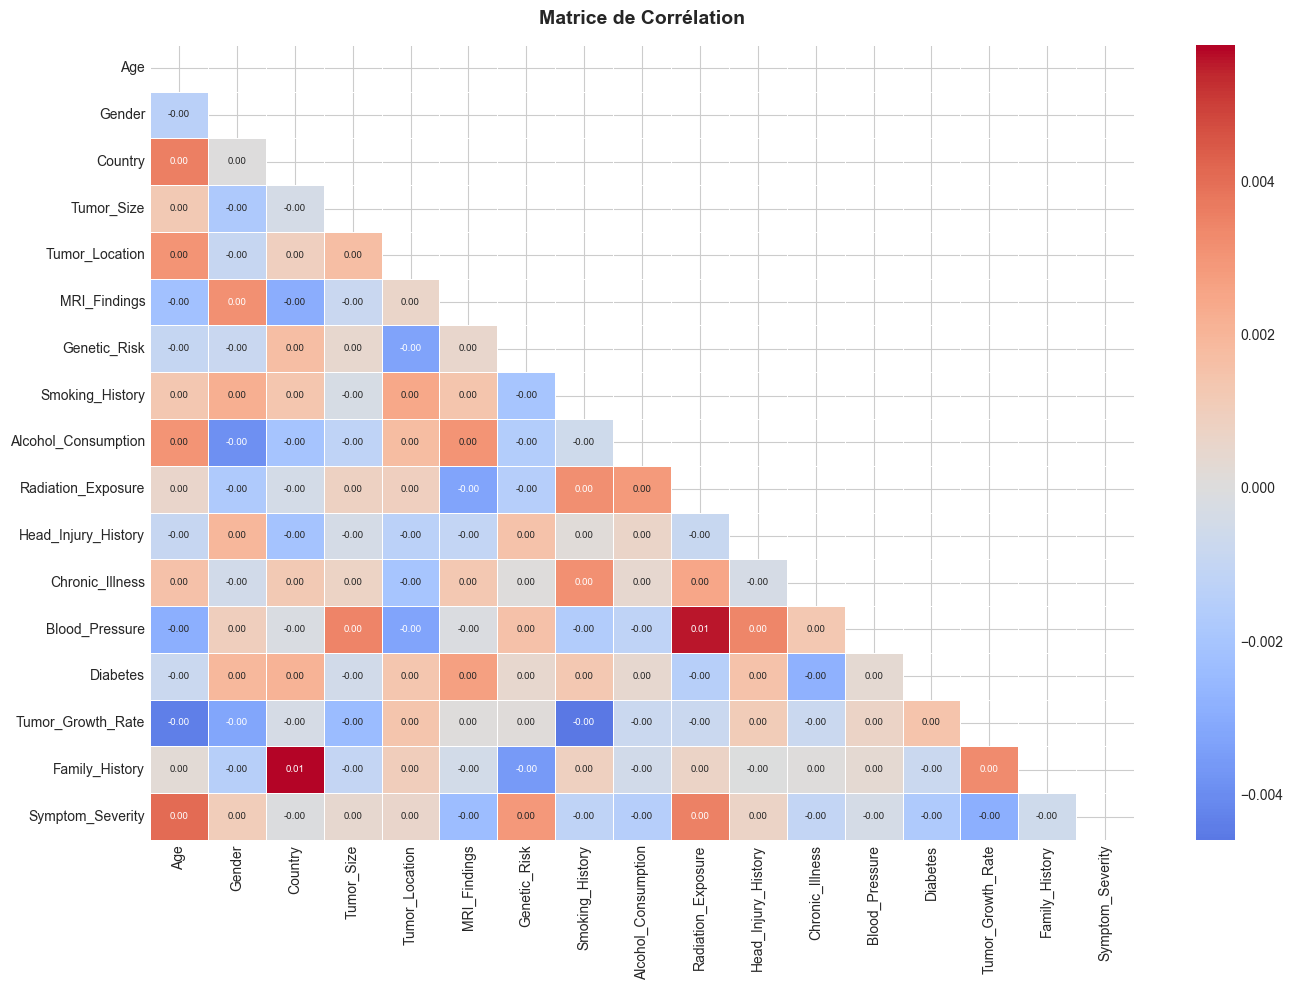

In [15]:
fig, ax = plt.subplots(figsize=(14, 10))
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # masque triangle supérieur

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 7}
)
ax.set_title('Matrice de Corrélation', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 3.2 — Distribution de Tumor_Size selon le statut tumeur


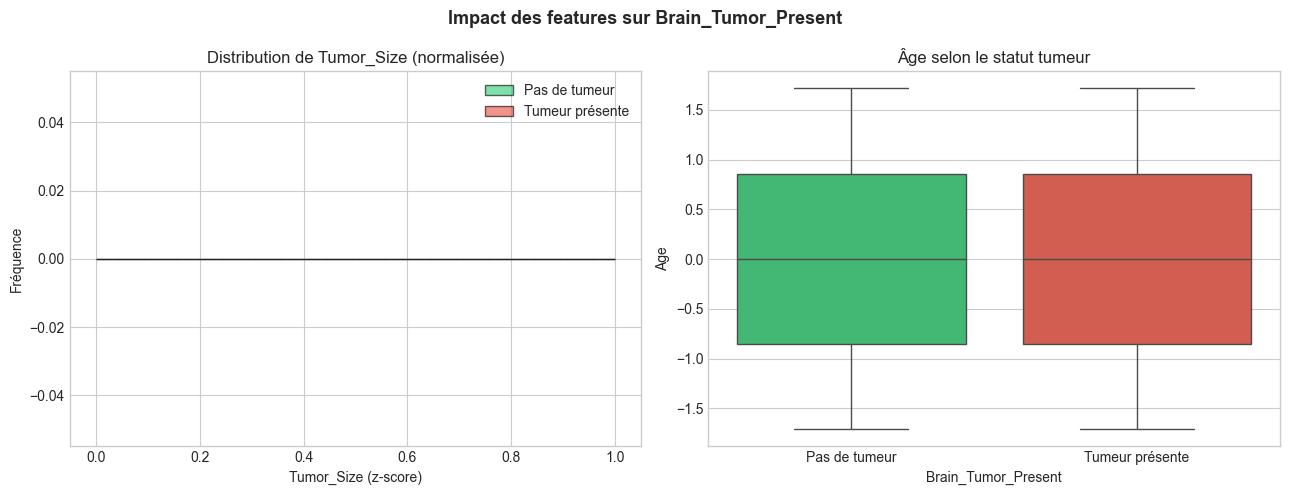

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impact des features sur Brain_Tumor_Present', fontsize=13, fontweight='bold')

# Histogramme Tumor_Size
for val, label, color in [(0, 'Pas de tumeur', '#2ecc71'), (1, 'Tumeur présente', '#e74c3c')]:
    subset = df_clean[df_clean['Brain_Tumor_Present'] == val]['Tumor_Size']
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='black')
axes[0].set_title('Distribution de Tumor_Size (normalisée)')
axes[0].set_xlabel('Tumor_Size (z-score)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Boxplot Age
sns.boxplot(data=df_clean, x='Brain_Tumor_Present', y='Age',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Âge selon le statut tumeur')
axes[1].set_xlabel('Brain_Tumor_Present')
axes[1].set_xticklabels(['Pas de tumeur', 'Tumeur présente'])

plt.tight_layout()
plt.show()

### 3.3 — Facteurs de risque clés


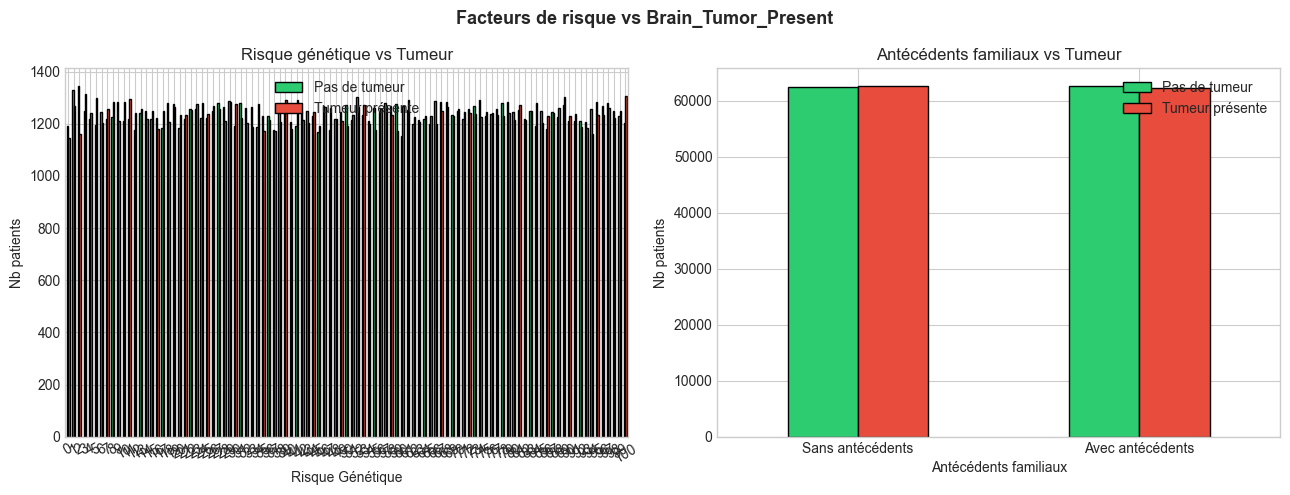

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Facteurs de risque vs Brain_Tumor_Present', fontsize=13, fontweight='bold')

# Risque génétique (dataset original non encodé)
genetic = df.groupby(['Genetic_Risk', 'Brain_Tumor_Present']).size().unstack(fill_value=0)
genetic.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Risque génétique vs Tumeur')
axes[0].set_xlabel('Risque Génétique')
axes[0].set_ylabel('Nb patients')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['Pas de tumeur', 'Tumeur présente'])

# Antécédents familiaux
fh = df.groupby(['Family_History', 'Brain_Tumor_Present']).size().unstack(fill_value=0)
fh.index = ['Sans antécédents', 'Avec antécédents']
fh.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Antécédents familiaux vs Tumeur')
axes[1].set_xlabel('Antécédents familiaux')
axes[1].set_ylabel('Nb patients')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Pas de tumeur', 'Tumeur présente'])

plt.tight_layout()
plt.show()

### 3.4 — Distribution de Tumor_Growth_Rate selon le type de tumeur


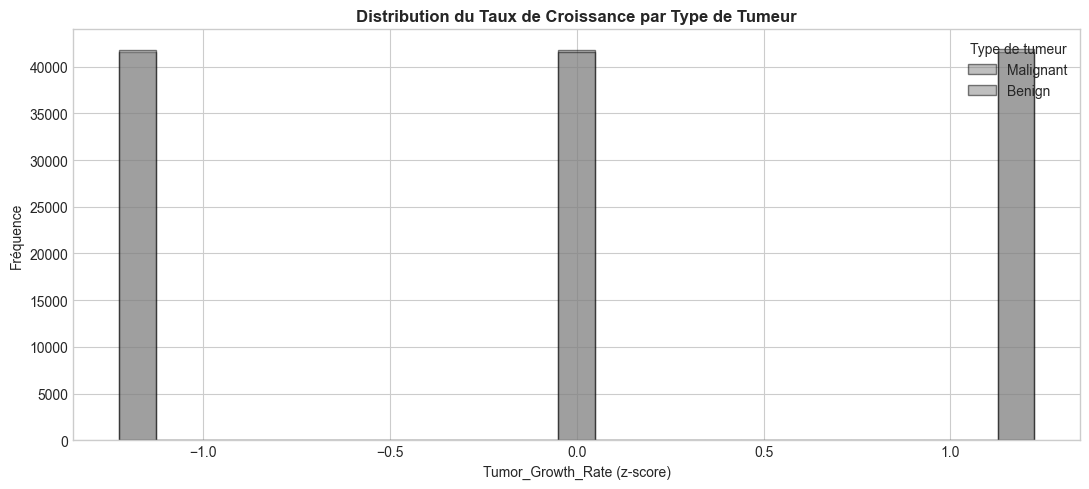

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
# On utilise df original (avant encodage) pour les étiquettes lisibles
tumor_types = df['Tumor_Type'].unique()
colors_map = {'Glioma': '#e74c3c', 'Meningioma': '#3498db',
              'Pituitary': '#9b59b6', 'No Tumor': '#2ecc71'}

for tt in tumor_types:
    subset = df_clean.loc[df['Tumor_Type'] == tt, 'Tumor_Growth_Rate']
    ax.hist(subset, bins=25, alpha=0.5, label=tt,
            color=colors_map.get(tt, 'grey'), edgecolor='black')

ax.set_title('Distribution du Taux de Croissance par Type de Tumeur', fontsize=12, fontweight='bold')
ax.set_xlabel('Tumor_Growth_Rate (z-score)')
ax.set_ylabel('Fréquence')
ax.legend(title='Type de tumeur')
plt.tight_layout()
plt.show()

---
<a id='section4'></a>
## ✂️ Section 4 — Préparation des Données pour le ML

On définit :
- **X** = toutes les colonnes sauf les cibles
- **y1** = `Brain_Tumor_Present` (0 ou 1)
- **y2** = `Tumor_Type` (Glioma, Meningioma, Pituitary, No Tumor)

Puis on divise en **80% entraînement / 20% test**.


In [19]:
# Encoder Tumor_Type en numérique pour y2
le_tumor = LabelEncoder()
df_clean['Tumor_Type_encoded'] = le_tumor.fit_transform(df_clean['Tumor_Type'].astype(str))

mapping = dict(enumerate(le_tumor.classes_))
print(f'Encodage Tumor_Type : {mapping}')

# ─── Définir X, y1, y2 ────────────────────────────────────────────────
exclude = ['Brain_Tumor_Present', 'Tumor_Type', 'Tumor_Type_encoded']
X  = df_clean.drop(columns=exclude)
y1 = df_clean['Brain_Tumor_Present']
y2 = df_clean['Tumor_Type_encoded']

print(f'\n📦 Features X     : {X.shape[1]} colonnes × {X.shape[0]} patients')
print(f'🎯 y1 classes     : {sorted(y1.unique())}')
print(f'🎯 y2 classes     : {sorted(y2.unique())}')

Encodage Tumor_Type : {0: 'Benign', 1: 'Malignant'}

📦 Features X     : 17 colonnes × 250000 patients
🎯 y1 classes     : ['No', 'Yes']
🎯 y2 classes     : [np.int64(0), np.int64(1)]


In [20]:
# ─── Split Train / Test (80% / 20%) ──────────────────────────────────────
# stratify=y1 garantit la même proportion de 0/1 dans train ET test

X_train, X_test, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42, stratify=y1
)
_, _, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f'✅ Split effectué :')
print(f'   Entraînement : {X_train.shape[0]} patients ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test         : {X_test.shape[0]} patients ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribution y1 dans train : {dict(y1_train.value_counts())}')
print(f'Distribution y1 dans test  : {dict(y1_test.value_counts())}')

✅ Split effectué :
   Entraînement : 200000 patients (80%)
   Test         : 50000 patients (20%)

Distribution y1 dans train : {'No': np.int64(100094), 'Yes': np.int64(99906)}
Distribution y1 dans test  : {'No': np.int64(25024), 'Yes': np.int64(24976)}


---
<a id='section5'></a>
## 🤖 Section 5 — Modélisation

### Modèles utilisés :

| Modèle | Cible | Type |
|---|---|---|
| Logistic Regression | Brain_Tumor_Present | Binaire |
| Random Forest (200 arbres) | Brain_Tumor_Present | Binaire |
| Random Forest (200 arbres) | Tumor_Type | Multi-classe |


### 5.1 — Régression Logistique (Brain_Tumor_Present)

> **C'est quoi ?** Un modèle simple qui trace une frontière linéaire entre les classes.
> Rapide, interprétable, bon point de départ.


In [21]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y1_train)
y1_pred_lr = lr.predict(X_test)
print('✅ Régression Logistique entraînée.')

✅ Régression Logistique entraînée.


### 5.2 — Random Forest (Brain_Tumor_Present)

> **C'est quoi ?** Un ensemble de 200 arbres de décision entraînés sur des
> sous-échantillons du dataset. Le vote majoritaire donne la prédiction finale.
> **Avantages** : robuste, gère les non-linéarités, donne l'importance des features.


In [22]:
rf1 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf1.fit(X_train, y1_train)
y1_pred_rf = rf1.predict(X_test)
print('✅ Random Forest (Binary) entraîné.')

✅ Random Forest (Binary) entraîné.


### 5.3 — Random Forest (Tumor_Type — Multi-classe)

> **Même algorithme**, mais cette fois il prédit parmi **4 classes** :
> Glioma, Meningioma, Pituitary, No Tumor.


In [23]:
rf2 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf2.fit(X_train, y2_train)
y2_pred_rf = rf2.predict(X_test)
print('✅ Random Forest (Multi-classe) entraîné.')

✅ Random Forest (Multi-classe) entraîné.


---
<a id='section6'></a>
## 📈 Section 6 — Évaluation des Modèles

### Métriques utilisées :

| Métrique | Définition simple |
|---|---|
| **Accuracy** | % de prédictions correctes au total |
| **Precision** | Parmi les positifs prédits, combien sont vrais positifs ? |
| **Recall** | Parmi tous les vrais positifs, combien a-t-on détectés ? |
| **F1-Score** | Moyenne harmonique de Precision et Recall |

> 🩺 En médical, le **Recall** est souvent plus important que la Precision
> (mieux vaut faux positif que faux négatif pour une tumeur).


In [24]:
def evaluer_modele_binaire(y_true, y_pred, nom_modele):
    """Calcule et affiche les métriques pour un modèle binaire."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f'┌─── {nom_modele} ───────────────────────────')
    print(f'│  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)')
    print(f'│  Precision : {prec:.4f}')
    print(f'│  Recall    : {rec:.4f}')
    print(f'│  F1-Score  : {f1:.4f}')
    print('└───────────────────────────────────────────')

    return {'model': nom_modele, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}

print('\n📊 RÉSULTATS — Brain_Tumor_Present\n')
res_lr = evaluer_modele_binaire(y1_test, y1_pred_lr, 'Logistic Regression')
print()
res_rf = evaluer_modele_binaire(y1_test, y1_pred_rf, 'Random Forest')


📊 RÉSULTATS — Brain_Tumor_Present



ValueError: pos_label=1 is not a valid label. It should be one of ['No', 'Yes']

In [ ]:
# ─── Matrices de confusion ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Matrices de Confusion — Brain_Tumor_Present', fontsize=13, fontweight='bold')

for ax, y_pred, title in zip(
    axes,
    [y1_pred_lr, y1_pred_rf],
    ['Régression Logistique', 'Random Forest']
):
    cm = confusion_matrix(y1_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prédit: Pas tumeur', 'Prédit: Tumeur'],
                yticklabels=['Réel: Pas tumeur', 'Réel: Tumeur'])
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ─── Comparaison visuelle des métriques ──────────────────────────────────
metrics = ['accuracy', 'precision', 'recall', 'f1']
lr_sc = [res_lr[m] for m in metrics]
rf_sc = [res_rf[m] for m in metrics]

x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, lr_sc, w, label='Logistic Regression', color='#3498db', edgecolor='black')
b2 = ax.bar(x + w/2, rf_sc, w, label='Random Forest',       color='#e74c3c', edgecolor='black')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
ax.set_title('Comparaison des Modèles — Brain_Tumor_Present', fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 — Évaluation de Tumor_Type (Multi-classe)


In [ ]:
print(f'Accuracy Random Forest (Tumor_Type) : {accuracy_score(y2_test, y2_pred_rf):.4f}')
print('\nRapport de classification détaillé :')
print(classification_report(y2_test, y2_pred_rf,
                             target_names=le_tumor.classes_, zero_division=0))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
cm2 = confusion_matrix(y2_test, y2_pred_rf)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=le_tumor.classes_,
            yticklabels=le_tumor.classes_)
ax.set_title('Matrice de Confusion — Tumor_Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.show()

---
<a id='section7'></a>
## 💡 Section 7 — Explication des Résultats


In [ ]:
# ─── Quel est le meilleur modèle ? ──────────────────────────────────────
best = 'Random Forest' if res_rf['f1'] > res_lr['f1'] else 'Logistic Regression'
best_f1 = max(res_rf['f1'], res_lr['f1'])
diff = abs(res_rf['f1'] - res_lr['f1'])

print('🏆 MEILLEUR MODÈLE (Brain_Tumor_Present)')
print('─' * 45)
print(f'   Modèle   : {best}')
print(f'   F1-Score : {best_f1:.4f}')
print(f'   Écart F1 vs autre modèle : {diff:.4f}')
print()
print('Pourquoi Random Forest est généralement supérieur ?')
print('  ✔ Combine des centaines d\'arbres → réduction du biais ET de la variance')
print('  ✔ Gère les relations non-linéaires entre variables')
print('  ✔ Robuste au bruit et aux outliers')
print('  ✔ Fonctionne bien même sans normalisation')

### 7.2 — Feature Importance (Brain_Tumor_Present)

> Quelles variables le modèle juge-t-il **les plus utiles** pour prédire ?


In [ ]:
fi = pd.Series(rf1.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(fi))]
fi.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='black')
ax.invert_yaxis()
ax.axvline(fi.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Moyenne ({fi.mean():.3f})')
ax.set_title('Feature Importance — Random Forest (Brain_Tumor_Present)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance relative')
ax.legend()
plt.tight_layout()
plt.show()

print('\n📌 Top 5 features les plus importantes :')
for i, (feat, score) in enumerate(fi.head(5).items(), 1):
    print(f'   {i}. {feat:28s} → {score:.4f}')

### 7.3 — Interprétation médicale

> Cette section traduit les résultats du modèle en **langage médical accessible**.


In [ ]:
top3 = fi.head(3).index.tolist()
print('🩺 INTERPRÉTATION MÉDICALE SIMPLE')
print('─' * 50)
print(f'\nLes 3 facteurs les plus influents : {top3}')
print('''
📋 Exemple d'interprétation (Brain_Tumor_Present) :

  "Un patient présentant une grande Tumor_Size,
   des résultats d'IRM anormaux (MRI_Findings = Abnormal)
   et des antécédents familiaux (Family_History = 1)
   a un risque significativement plus élevé d'avoir
   une tumeur cérébrale."

📋 Interprétation pour Tumor_Type :

  "Le type de tumeur est souvent influencé par :
   - La localisation (Tumor_Location)
   - L'âge du patient (Age)
   - Le risque génétique (Genetic_Risk)
   - L'exposition aux radiations (Radiation_Exposure)
   Les Gliomes sont souvent associés à un taux de
   croissance plus élevé et un risque génétique élevé."
''')

---
<a id='section8'></a>
## 🎁 Section 8 — Bonus

### 8.1 — Feature Importance pour Tumor_Type


In [ ]:
fi2 = pd.Series(rf2.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
fi2.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='black')
ax.invert_yaxis()
ax.set_title('Feature Importance — Random Forest (Tumor_Type)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance relative')
plt.tight_layout()
plt.show()

print('Top 5 features pour Tumor_Type :')
for i, (feat, score) in enumerate(fi2.head(5).items(), 1):
    print(f'   {i}. {feat:28s} → {score:.4f}')

### 8.2 — 🆕 Prédiction sur un nouveau patient

> Simulons le cas d'un nouveau patient qui arrive en consultation.
> On entre ses données et le modèle prédit si une tumeur est présente et son type.


In [ ]:
# ─── Profil du nouveau patient ───────────────────────────────────────────
nouveau_patient = {
    'Age': 45,
    'Gender': 'Male',
    'Country': 'France',
    'Tumor_Size': 7.2,
    'Tumor_Location': 'Frontal',
    'MRI_Findings': 'Abnormal',
    'Genetic_Risk': 'High',
    'Smoking_History': 1,
    'Alcohol_Consumption': 0,
    'Radiation_Exposure': 1,
    'Head_Injury_History': 0,
    'Chronic_Illness': 1,
    'Blood_Pressure': 'High',
    'Diabetes': 1,
    'Tumor_Growth_Rate': 3.5,
    'Family_History': 1,
    'Symptom_Severity': 'Severe'
}

print('Profil du patient :')
for k, v in nouveau_patient.items():
    print(f'  {k:25s}: {v}')

In [ ]:
# ─── Préparer le patient pour la prédiction ──────────────────────────────
le_np = LabelEncoder()
np_df = pd.DataFrame([nouveau_patient])

cat_np = ['Gender', 'Country', 'Tumor_Location', 'MRI_Findings',
          'Genetic_Risk', 'Blood_Pressure', 'Symptom_Severity']
for col in cat_np:
    np_df[col] = le_np.fit_transform(np_df[col].astype(str))

# Aligner les colonnes
for col in X.columns:
    if col not in np_df.columns:
        np_df[col] = 0
np_df = np_df[X.columns]

# Normaliser
np_scaled = scaler.transform(np_df)

# ─── Prédictions ──────────────────────────────────────────────────────────
pred_present = rf1.predict(np_scaled)[0]
pred_proba   = rf1.predict_proba(np_scaled)[0]
pred_type_enc = rf2.predict(np_scaled)[0]
pred_type_lb  = le_tumor.inverse_transform([pred_type_enc])[0]

print('\n' + '═'*50)
print('    RÉSULTATS DE PRÉDICTION')
print('═'*50)
status = '🔴 TUMEUR DÉTECTÉE' if pred_present == 1 else '🟢 PAS DE TUMEUR'
print(f'\n  Brain_Tumor_Present : {pred_present} → {status}')
print(f'  Probabilités        : [Pas de tumeur = {pred_proba[0]*100:.1f}% | Tumeur = {pred_proba[1]*100:.1f}%]')
print(f'  Type de tumeur      : {pred_type_lb}')
print('═'*50)

### 8.3 — 📋 Recommandations pour améliorer le modèle


In [ ]:
recommandations = [
    ('📦 Plus de données',
     '10 000+ patients améliore drastiquement la généralisation'),
    ('⚖️  Gestion déséquilibre',
     'Utiliser SMOTE ou class_weight="balanced" si classes déséquilibrées'),
    ('🔍 Tuning hyperparamètres',
     'GridSearchCV / RandomizedSearchCV pour optimiser n_estimators, max_depth...'),
    ('🧠 Modèles avancés',
     'XGBoost, LightGBM, CatBoost → souvent +2-5% accuracy sur données médicales'),
    ('🔬 Cross-validation',
     'Remplacer le split 80/20 par k-fold (k=5 ou 10) pour une évaluation plus robuste'),
    ('🩻 Features supplémentaires',
     'Ajouter marqueurs biologiques (CRP, WBC, lymphocytes) si disponibles'),
    ('📈 Courbe ROC / AUC',
     'Comparer les modèles sur l\'AUC, plus pertinent que l\'accuracy pour données médicales'),
    ('🌐 SHAP — Explicabilité',
     'Utiliser la librairie SHAP pour expliquer chaque prédiction individuelle (crucial pour médecins)'),
]

print('\n📋 RECOMMANDATIONS POUR AMÉLIORER LE MODÈLE')
print('─' * 65)
for i, (titre, detail) in enumerate(recommandations, 1):
    print(f'\n  {i}. {titre}')
    print(f'     → {detail}')

---

## ✅ Conclusion

Ce pipeline complet couvre toutes les étapes d'un projet Data Science médical :

| Étape | Action clé |
|---|---|
| Analyse | Comprendre la structure et la qualité des données |
| Nettoyage | Éliminer data leakage, imputer, encoder, normaliser |
| EDA | Visualiser les relations entre variables |
| Modélisation | Régression Logistique + Random Forest |
| Évaluation | Accuracy, F1, Recall, matrices de confusion |
| Interprétation | Feature Importance + sens médical |
| Bonus | Prédiction patient + recommandations |

> 🚀 **Prochaines étapes recommandées** : XGBoost, SHAP, cross-validation k-fold, collecte de plus de données.
